In [1]:
from pytential.sympy_pytential import sympy_pytential
from pytential.reduce import min_pytential
import numpy as np
from sympy import log, symbols,lambdify
import matplotlib.pyplot as plt

This file demonstrates how to create, combine, and manipulate pytentials.  Equibilriation is used to reduce free variables. 

# Create phases

In [2]:
xa, xb, x = symbols('xa xb x')

In [3]:
RT = 8.134*300
fa_sp = xa*RT*(1+log(xa)) +(1-xa)*RT*log(1-xa)
fb_sp = xb*RT*log(xb) +(1-xb)*RT*(1+log(1-xb))

In [4]:
fa = sympy_pytential(fa_sp)
fb = sympy_pytential(fb_sp)
print(fa)


Variables
['xa']

Potential
2440.2*xa*(log(xa) + 1) + (2440.2 - 2440.2*xa)*log(1 - xa)

Gradient
[2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2]

Hessian
[[-2440.2/(xa*(xa - 1))]]



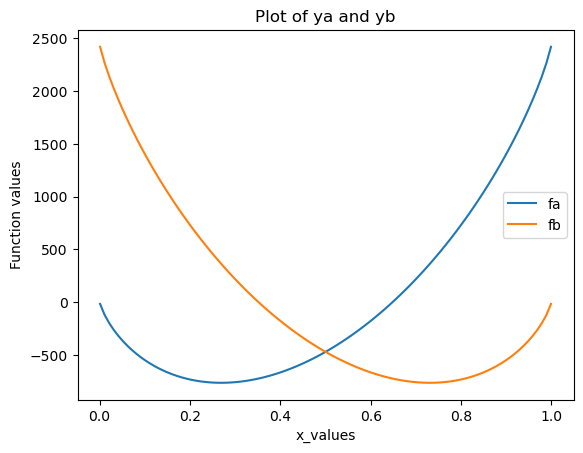

In [5]:
x_values = np.linspace(0.001, .999, 100);
ya = fa([x_values])
yb = fb([x_values])

plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.xlabel('x_values')
plt.ylabel('Function values')
plt.title('Plot of ya and yb')
plt.legend()
plt.show()

# Combine functions

Combine functions into a composite pytential

In [6]:
f = fa+fb
print(f)


Variables
['xa', 'xb']

Potential
2440.2*xa*(log(xa) + 1) + 2440.2*xb*log(xb) + (2440.2 - 2440.2*xa)*log(1 - xa) + (2440.2 - 2440.2*xb)*(log(1 - xb) + 1)

Gradient
[2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2, 2440.2*log(xb) - 2440.2*log(1 - xb) - 2440.2]

Hessian
[[-2440.2/(xa*(xa - 1)), 0], [0, -2440.2/(xb*(xb - 1))]]



Add a constraint for the total x. Note the function is now an argument of x1, x2, and x

In [7]:
f_constrained = f.add_constraints_sym([xa+xb-x])
print(f_constrained)


Variables
['x', 'xa', 'xb']

Potential
2440.2*xa*(log(xa) + 1) + 2440.2*xb*log(xb) + (2440.2 - 2440.2*xa)*log(1 - xa) + (2440.2 - 2440.2*xb)*(log(1 - xb) + 1)

Gradient
[0, 2440.2*log(xa) - 2440.2*log(1 - xa) + 2440.2, 2440.2*log(xb) - 2440.2*log(1 - xb) - 2440.2]

Hessian
[[0, 0, 0], [0, -2440.2/(xa*(xa - 1)), 0], [0, 0, -2440.2/(xb*(xb - 1))]]

Constraints
-x + xa + xb



In [ ]:
f_constrained([.5, .5, .5])
f_constrained.constraints[0](xa = .5, xb = .5, x = .5)

TypeError: _lambdifygenerated() got an unexpected keyword argument 'xa'

In [ ]:
print(f_constrained.vars)


['x', 'xa', 'xb']


/usr/lib/python3/dist-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


KeyboardInterrupt: 

Reduce the space of the composite pytential through minimization

In [9]:
f_min = min_pytential(f_constrained, 'x')
print(f_min)

cont []
Pytential of type <class 'pytential.reduce.min_pytential.min_pytential'>
Variables: x
Potential: <bound method args_to_list.<locals>.wrapper of <pytential.reduce.min_pytential.min_pytential object at 0x7801f54b9640>>
Gradient: <bound method args_to_list.<locals>.wrapper of <pytential.reduce.min_pytential.min_pytential object at 0x7801f54b9640>>
Hessian: <bound method args_to_list.<locals>.wrapper of <pytential.reduce.min_pytential.min_pytential object at 0x7801f54b9640>>



In [86]:
vars = f_constrained.vars
free_vars = ['x']
print(vars)
print(free_vars)
print('hi', [vars.index(name) for name in free_vars])


dep_idx  = [i for i, name in enumerate(vars) if name not in free_vars]
free_idx = [i for i, name in enumerate(vars) if name in free_vars]
free_indx = np.array(free_indicies, dtype=int)
print(free_indx)

print(dependent_indicies)
full_values = np.empty_like(vars, dtype=object)
full_values[free_indices] = [.4]
full_values[dependent_indicies] = [.1,.2]
print(full_values)

['x', 'xa', 'xb']
['x']
hi [0]
[0]
[-1]


ValueError: could not broadcast input array from shape (2,) into shape (1,)

In [74]:
f = np.empty(2)
a[1]=1
print(f)

NameError: name 'a' is not defined

In [ ]:
import numpy as np
from functools import wraps

def partial_vector_copy(f, *,
                        fixed_idx: np.ndarray,
                        fixed_vals: np.ndarray,
                        total_len: int):
    """
    Return g(x_free) := f(x) where
      - x is length total_len
      - x[fixed_idx] = fixed_vals
      - the rest of x comes from the input x_free
    This version copies a template array on each call.
    """
    fixed_idx = np.array(fixed_idx, dtype=int)
    fixed_vals = np.array(fixed_vals, dtype=float)
    # compute which indices are free
    all_idx  = np.arange(total_len)
    free_idx = np.setdiff1d(all_idx, fixed_idx)

    @wraps(f)
    def g(x_free: np.ndarray):
        x = np.empty(total_len, dtype=x_free.dtype)
        x[fixed_idx] = fixed_vals
        x[free_idx]  = x_free
        return f(x)

    return g


In [48]:
fixed_vars = {'x': 0.5}
partial_fcn = create_partial_function(f_constrained.fcn, f_constrained.vars, fixed_vars)
partial_const = create_partial_function(f_constrained.constraints[0], f_constrained.vars, fixed_vars)
result = partial_fcn([0.3, 0.2])  # xa=0.3, xb=0.2
print("Partial function result:", result)
result = partial_const([0.3, 0.2])  # xa=0.3, xb=0.2
print("Partial constraint result:", result)



Partial function result: -27.493063792237308
Partial constraint result: 0.0


In [56]:
from scipy.optimize import differential_evolution, shgo, NonlinearConstraint
bounds = [(0.0001, .9999)] * 2
nlc = NonlinearConstraint(partial_const, 0, 0)
obj = partial_fcn

In [55]:
res = differential_evolution(
    partial_fcn, bounds,
    constraints=(nlc,),
    updating="deferred",
    maxiter=500,
    tol=1e-6,
    polish=True
)
print("DE solution:", dict(zip(f_constrained.vars, res.x)))
print("Objective value:", res.fun)

DE solution: {'x': 0.08695516537720666, 'xa': 0.4130448346227934}
Objective value: -730.7747084146873
